In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model = keras.models.load_model('dogs-vs-cats.h5')

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('clothing-model.tflite','wb') as f_out:
    f_out.write(tflite_model)

In [5]:
!ls -lh clothing-model.tflite

-rw-rw-rw- 1 codespace codespace 43M Dec 21 12:32 clothing-model.tflite


In [1]:
import tensorflow.lite as tflite

2025-12-21 12:45:35.872615: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-21 12:45:41.443973: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-21 12:45:48.756822: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
interpreter = tflite.Interpreter(model_path='clothing-model.tflite')
interpreter.allocate_tensors()

input_index = interpreter.get_input_details()[0]['index']
output_index = interpreter.get_output_details()[0]['index']

/opt/conda/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [6]:
output_index

18

In [21]:
from io import BytesIO
from urllib import request

from PIL import Image

def download_image(url): 
    req = request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"})
    
    with request.urlopen(req) as resp:
        buffer = resp.read()
    stream = BytesIO(buffer)
    img = Image.open(stream)
    return img


def prepare_image(img, target_size):
    if img.mode != 'RGB':
        img = img.convert('RGB')
    img = img.resize(target_size, Image.NEAREST)
    return img

In [22]:
Image

<module 'PIL.Image' from '/home/codespace/.local/lib/python3.12/site-packages/PIL/Image.py'>

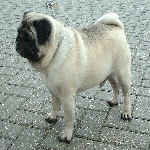

In [24]:
img = download_image('https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg')
img = prepare_image(img, target_size=(150,150))
img

In [25]:
import numpy as np

In [27]:
def prepare_input(x):
    return x / 255.0

In [33]:
x = np.array(img, dtype='float32')
X = np.array([x])
X = prepare_input(X)

In [30]:
X[0,0,0,0]

np.float64(0.7058823529411765)

In [34]:
interpreter.set_tensor(input_index, X)
interpreter.invoke()

preds = interpreter.get_tensor(output_index)

In [35]:
preds

array([[0.76991]], dtype=float32)